##   **Step 2: Dataset Loading & Exploratory Data Analysis**

## **2.1  Load & Inspect**


## import libararies

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.preprocessing import StandardScaler,LabelEncoder

## Dataset Loading

In [52]:
df = pd.read_csv('Customer-Churn.csv')

## Baic Information

In [53]:
df.shape

(7043, 21)

In [54]:
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [55]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [56]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

## Target column counts

In [57]:
df['Churn'].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

## Target column counts %

In [58]:
df['Churn'].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

## convert str to flot

In [59]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'],errors='coerce')


In [60]:
print(df.dtypes)

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object


## Null values

In [61]:
df['TotalCharges'].isnull().sum()

np.int64(11)

## Fill null values with Median

In [62]:
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

In [63]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## **2.2  Univariate Analysis**


## Count plot of Churn

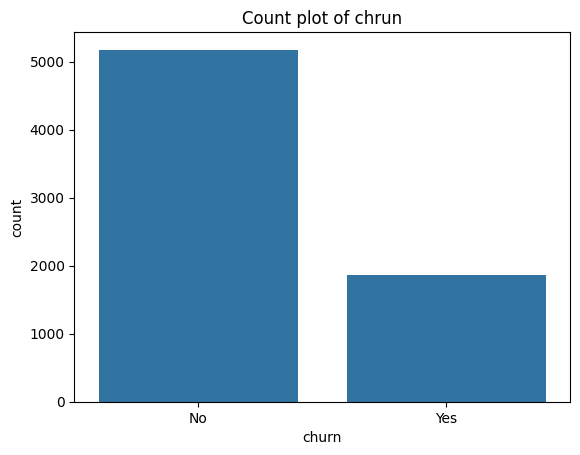

In [64]:
sns.countplot(df,x=df['Churn'])
plt.xlabel('churn')
plt.title('Count plot of chrun')
plt.show()

## Histogram

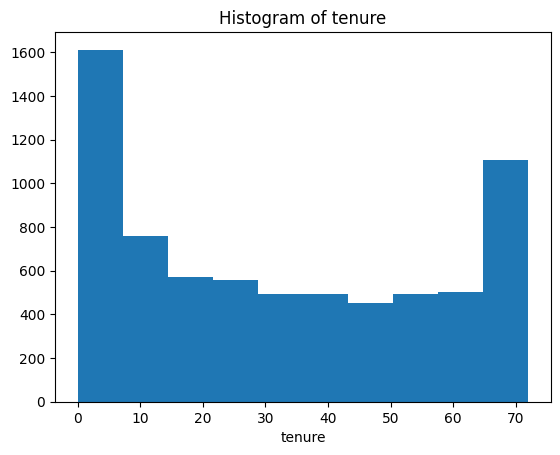

In [65]:
plt.hist(df['tenure'])
plt.xlabel('tenure')
plt.title('Histogram of tenure')
plt.show()

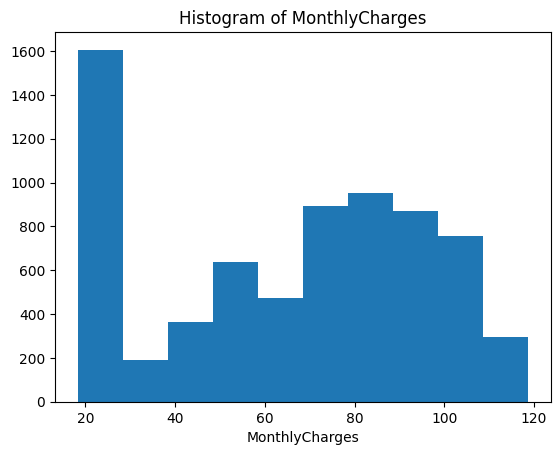

In [66]:
plt.hist(df['MonthlyCharges'])
plt.xlabel('MonthlyCharges')
plt.title('Histogram of MonthlyCharges')
plt.show()

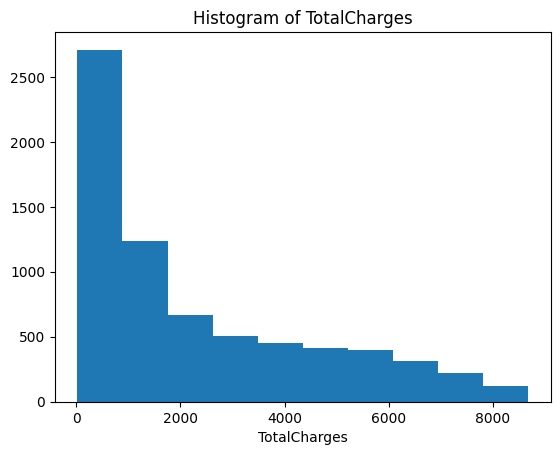

In [67]:
plt.hist(df['TotalCharges'])
plt.xlabel('TotalCharges')
plt.title('Histogram of TotalCharges')
plt.show()

## Count plot 

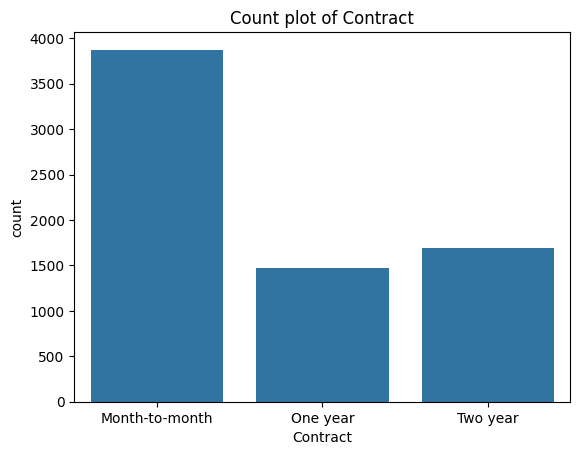

In [68]:
sns.countplot(df,x=df['Contract'])
plt.xlabel('Contract')
plt.title('Count plot of Contract')
plt.show()

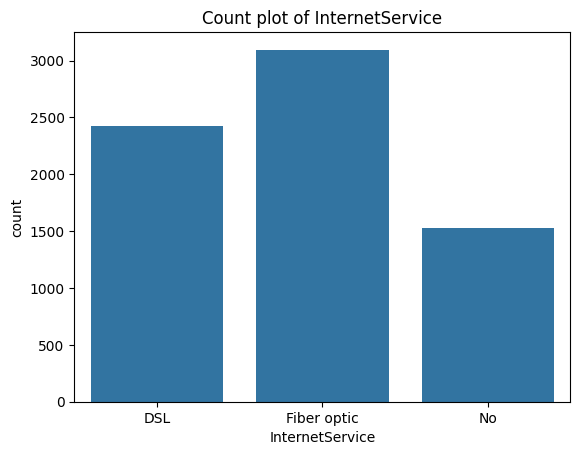

In [69]:
sns.countplot(df,x=df['InternetService'])
plt.xlabel('InternetService')
plt.title('Count plot of InternetService')
plt.show()

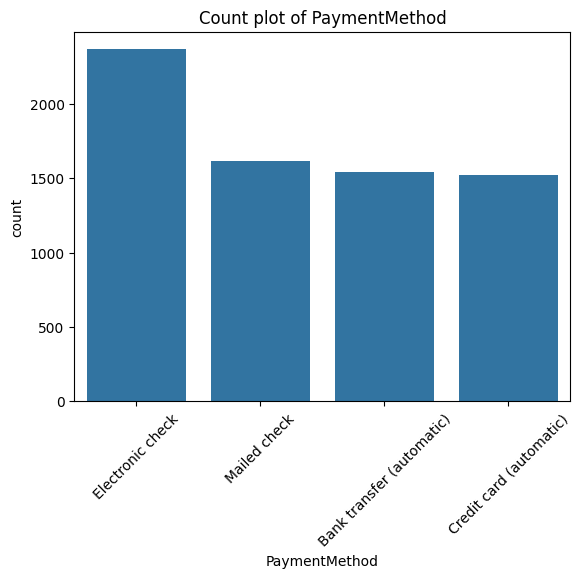

In [70]:
sns.countplot(df,x=df['PaymentMethod'])
plt.xlabel('PaymentMethod')
plt.title('Count plot of PaymentMethod')
plt.xticks(rotation=45)
plt.show()

## **2.3  Bivariate Analysis**


## Contract Group by churn

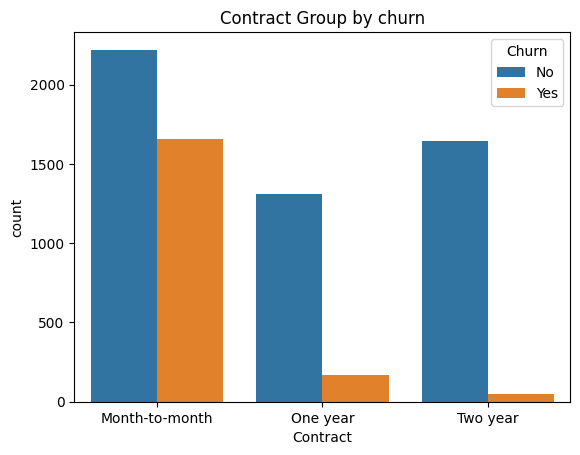

In [71]:
sns.countplot(x='Contract',hue='Churn',data=df)
plt.title('Contract Group by churn')
plt.show()


## tenure_bucket grouped by churn

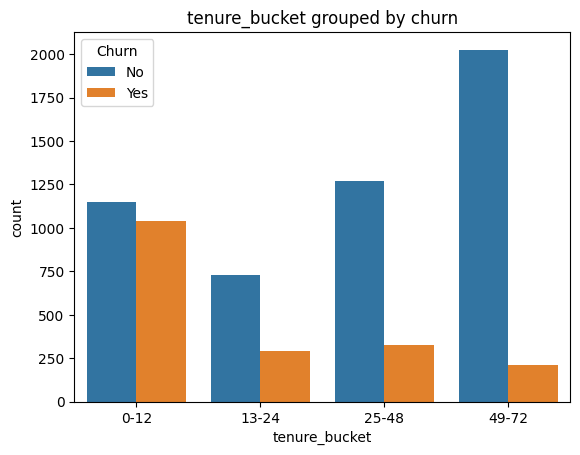

In [72]:
df['tenure_bucket']=pd.cut(df['tenure'],bins=[0,12,24,48,72],labels=['0-12','13-24','25-48','49-72'],include_lowest=True)


sns.countplot(x='tenure_bucket',hue='Churn',data=df)
plt.title('tenure_bucket grouped by churn')
plt.show()


## Boxplot(MonthlyCharges Vs Churn)

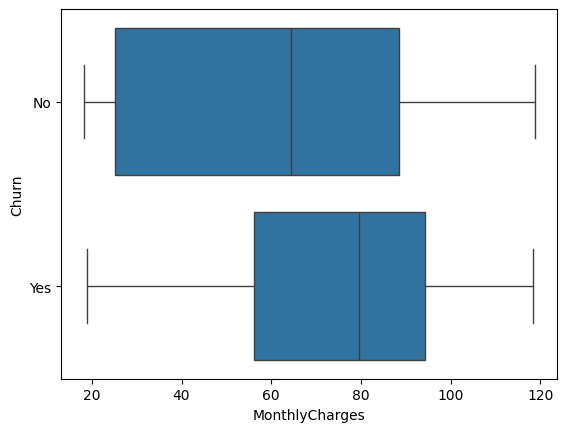

In [73]:
sns.boxplot(df,x=df['MonthlyCharges'],y=df['Churn'])
plt.xlabel('MonthlyCharges')
plt.ylabel('Churn')
plt.show()

## Numerical column

In [74]:
num_column = df.select_dtypes('number').columns.to_list()
print(num_column)

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


## Heatmap

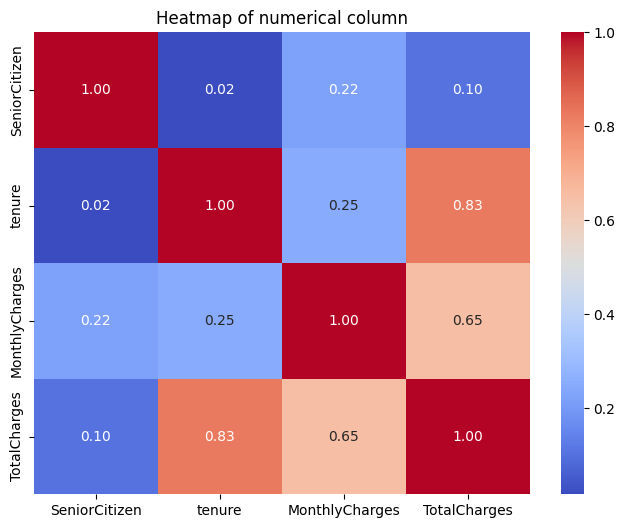

In [75]:
plt.figure(figsize=(8,6))

sns.heatmap(df.corr(numeric_only=True),annot=True,fmt='.2f',cmap='coolwarm')
plt.title('Heatmap of numerical column')
plt.show()

##  **Step 3: Data Preprocessing & Feature Engineering**


## **3.1  Drop & Clean**


In [76]:
df=df.drop(columns=['customerID'])


## **3.2  Feature Engineering**


In [77]:
service_cols=['OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']


In [78]:
df['tenure_group']=pd.cut(df['tenure'],bins=[0,12,36,60,np.inf],labels=['New','Mid','Senior','Loyal'],include_lowest=True)


In [79]:
df['num_services']=(df[service_cols]=='Yes').sum(axis=1)


In [80]:
df['AutoPay']=df['PaymentMethod'].str.contains('automatic',case=False).astype(int)


## **3.3  Encoding**


## Binary columns

In [81]:
binary=['Partner','Dependents','PhoneService','PaperlessBilling','Churn']
for c in binary:
 df[c]=df[c].map({'Yes':1,'No':0})


In [82]:
binary_cols = [
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies']



In [83]:
for t in binary_cols:
    df[t] = df[t].map({'Yes':1,'No':0,'No internet service':2})

##  One-Hot Encoding

In [84]:
df=pd.get_dummies(df,columns=['InternetService','Contract','PaymentMethod','gender','MultipleLines'],drop_first=False,dtype=int)


##  Label Encoding

In [85]:
encoder=LabelEncoder()
df['tenure_group']=encoder.fit_transform(df['tenure_group'])


## **3.4  Scaling**


## StandardScaler 

In [86]:
scaler=StandardScaler()
scaling_cols=['tenure','MonthlyCharges','TotalCharges','num_services']
df[scaling_cols]=scaler.fit_transform(df[scaling_cols])


In [87]:
df.drop(columns='tenure_bucket',inplace=True)

## Feature selection

In [88]:
x=df.drop('Churn',axis=1)
y=df['Churn']


## **3.6  Train-Test Split**


In [89]:
from sklearn.model_selection import train_test_split

In [90]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)


## **3.5  Handle Class Imbalance**


In [91]:
print('BEFORE SMOTE:')
print(y_train.value_counts())

BEFORE SMOTE:
Churn
0    4139
1    1495
Name: count, dtype: int64


In [92]:
from imblearn.over_sampling import SMOTE

In [93]:
smote = SMOTE()


In [94]:
x_train_smote,y_train_smote = smote.fit_resample(x_train,y_train)

In [95]:
print('AFTER SMOTE:')
print(y_train_smote.value_counts())

AFTER SMOTE:
Churn
0    4139
1    4139
Name: count, dtype: int64


In [96]:
x_train.shape

(5634, 32)

In [97]:
x_test.shape

(1409, 32)

In [98]:
y_train.shape

(5634,)

In [99]:
y_test.shape

(1409,)

In [100]:
df.to_csv('Main_clean_data.csv',index=False)

# 🧹 Data Preprocessing

## 📊 Data Preprocessing Summary

| Step | Description |
|------|-------------|
| Dataset Loading | Loaded the Telco Customer Churn dataset into a Pandas DataFrame. |
| Initial Data Inspection | Examined the dataset using `head()`, `shape`, `info()`, and `describe()` to understand its structure and data types. |
| Missing Value Analysis | Identified missing values and converted the `TotalCharges` column to numeric format. |
| Missing Value Handling | Replaced missing values in `TotalCharges` with the median value to preserve data consistency. |
| Duplicate Check | Verified that the dataset contained no duplicate records. |
| Data Type Conversion | Converted categorical variables into appropriate numerical representations where necessary. |
| Exploratory Data Analysis (EDA) | Performed univariate and bivariate analysis using count plots, histograms, box plots, and correlation heatmaps. |
| Outlier Analysis | Visualized numerical features using box plots to inspect potential outliers. |
| Feature Engineering | Created new features such as `tenure_group`, `num_services`, and `AutoPay` to improve model performance. |
| Feature Encoding | Applied Label Encoding and One-Hot Encoding to convert categorical variables into numerical format. |
| Feature Scaling | Standardized numerical features using `StandardScaler` to ensure equal feature contribution during model training. |
| Train-Test Split | Split the dataset into training and testing sets using an 80:20 ratio while preserving class distribution through stratification. |
| Class Imbalance Handling | Applied SMOTE (Synthetic Minority Oversampling Technique) on the training dataset to balance the minority churn class. |
| Final Dataset | Obtained a fully cleaned, transformed, encoded, scaled, and balanced dataset ready for machine learning model development. |

---

# 📈 Exploratory Data Analysis (EDA)

## 📊 Analysis Performed

| Analysis | Purpose |
|----------|---------|
| Churn Distribution | Examined the class distribution between churn and non-churn customers. |
| Numerical Feature Distribution | Analyzed the distribution of `tenure`, `MonthlyCharges`, and `TotalCharges`. |
| Categorical Feature Distribution | Visualized the frequency of Contract Type, Internet Service, Payment Method, Gender, Partner, Dependents, and other customer attributes. |
| Bivariate Analysis | Studied the relationship between customer features and churn status. |
| Correlation Analysis | Generated a correlation heatmap to identify relationships among numerical features. |
| Box Plot Analysis | Detected potential outliers in numerical variables. |

---

# ⚙️ Feature Engineering

## 📊 Newly Created Features

| Feature | Description |
|---------|-------------|
| `tenure_group` | Categorized customer tenure into meaningful groups representing customer loyalty. |
| `num_services` | Calculated the total number of subscribed services for each customer. |
| `AutoPay` | Created a binary feature indicating whether the customer uses automatic payment methods. |

---

# 🔄 Data Transformation

## 📊 Transformation Steps

| Technique | Purpose |
|-----------|---------|
| Label Encoding | Converted binary categorical variables into numerical values. |
| One-Hot Encoding | Converted multi-class categorical variables into dummy variables. |
| StandardScaler | Standardized numerical features to have zero mean and unit variance. |
| SMOTE | Balanced the training dataset by generating synthetic samples for the minority churn class. |

---

# ✅ Final Preprocessing Conclusion

The Telco Customer Churn dataset was successfully preprocessed by performing data cleaning, missing value treatment, feature engineering, categorical encoding, feature scaling, and class imbalance handling. Exploratory Data Analysis provided valuable insights into customer behavior and churn patterns, while newly engineered features enhanced the dataset with additional predictive information. Standardization ensured consistent feature scaling, and SMOTE effectively balanced the minority class to reduce model bias during training. The final processed dataset was clean, numerically encoded, balanced, and fully prepared for building and evaluating machine learning classification models.